In [1]:
from pathlib import Path
from lightning.pytorch import seed_everything
import pandas as pd
import numpy as np
import torch
import scvi
import scanpy as sc
import squidpy as sq
import cellcharter as cc
import matplotlib.pyplot as plt
import sys
sys.path.append('../../scripts')

import readwrite
cfg = readwrite.config()
seed_everything(0)
torch.set_float32_matmul_precision('medium')

def concat_samples(ads, correction_method, segmentation, condition=None, panel=None):
    ads_corr_method = ads[correction_method]

    def is_match(key):
        return (
            segmentation in key and
            (condition is None or condition in key) and
            (panel is None or panel in key)
        )

    adata = sc.concat({k: v for k, v in ads_corr_method.items() if is_match(k)},label='dataset_id', join='outer')
    adata.obs[xenium_levels] = pd.DataFrame(adata.obs['dataset_id'].tolist(),index=adata.obs.index,columns=xenium_levels)
    return adata

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/work/PRTNR/CHUV/DIR/rgottar1/spatia

### Paths and parameters

In [2]:
# paths
xenium_dir = Path(cfg['xenium_processed_dir'])
xenium_count_correction_dir = Path(cfg['xenium_count_correction_dir'])
xenium_std_seurat_analysis_dir = Path(cfg['xenium_std_seurat_analysis_dir'])
xenium_cell_type_annotation_dir = Path(cfg['xenium_cell_type_annotation_dir'])
results_dir = Path(cfg['results_dir'])

# parameters
xenium_levels = ['segmentation','condition','panel','donor','sample']
correction_methods = ['raw','split_fully_purified']
normalisation = 'lognorm'
layer = 'data'
reference = 'GEO_GSE178341'
method = 'rctd_class_aware'
level = 'Level1'

### Read all xenium samples

In [ ]:
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,

    # (optional) read only some parameter combinations
    correction_methods_filter=correction_methods,
    # segmentations_filter=segmentations,
    # conditions_filter=,
    # panels_filter=
)


# set transcripts=True to load individual transcripts positions)
ads = readwrite.read_count_correction_samples(xenium_paths,[c for c in correction_methods if c != 'raw'])
ads['raw'] = readwrite.read_xenium_samples(
    xenium_paths['raw'],  
    anndata=True, 
    pool_mode="thread",
    max_workers=6
)

# info about the loaded cohort
df_cohort_info = pd.DataFrame([k+(corr_method,) for corr_method in correction_methods for k in ads[corr_method].keys() ], columns=xenium_levels+['correction_method'])

Processing split_fully_purified: 100%|██████████| 176/176 [00:38<00:00,  4.62it/s]
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial

INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_5um/CRC/
         hImmune_v1_mm/OIYM/HCC_output-XETG00209__0003786__OIYM__20250503__073331/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             
INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_5um/CRC/
         hImmune_v1_mm/1EGQ/output-XETG00059__0053261__1EGQ__20250306__164822/normalised_results/outs/cell_feature_
         matrix.h5                                                                                                 


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/anndata/_core/anndata.py:831: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  names = self._prep_dim_index(names, "obs")


INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_5um/CRC/
         hImmune_v1_mm/14V5/output-XETG00059__0053259__14V5__20250306__164822/normalised_results/outs/cell_feature_
         matrix.h5                                                                                                 


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_o

...

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is

INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/OUC1/output-XETG00059__0021738__OUC1__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/fun

INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/OAFN/output-XETG00059__0021738__OAFN__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             
INFO     reading                                                                                                   
         /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/segmentation/10x_0um/CRC_
         PDO/hImmune_v1_mm/O056/output-XETG00059__0021741__O056__20250319__172035/normalised_results/outs/cell_feat
         ure_matrix.h5                                                                                             


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is not supported yet. Please report this issue.
  return f(*args, **kwargs)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_labels', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdata_io/_utils.py:47: UserWarning: The "cell_id" column in the cells metadata table does not match the "cell_id" column in the annotation table. This could be due to trying to read a new version that is

# Cellcharter

In [ ]:
# input params
correction_method = 'raw'
segmentation = 'proseg_expected'
condition = 'CRC'
panel = 'hImmune_v1_mm'

xenium_dir = Path(cfg['xenium_processed_dir'])
xenium_count_correction_dir = Path(cfg['xenium_count_correction_dir'])
xenium_std_seurat_analysis_dir = Path(cfg['xenium_std_seurat_analysis_dir'])
xenium_cell_type_annotation_dir = Path(cfg['xenium_cell_type_annotation_dir'])
results_dir = Path(cfg['results_dir'])

xenium_levels = ['segmentation','condition','panel','donor','sample']
normalisation = 'lognorm'
reference = 'GEO_GSE178341'
method = 'rctd_class_aware'
level = 'Level1'


# fixed params
BATCH_KEY = 'dataset_id'
SPATIAL_KEY = 'spatial'
N_CLUSTERS_RANGE = (5,19)
MAX_RUNS = 10
CONVERGENCE_TOL = 0.001
OUTPUT_LABELS = results_dir/'xenium/cellcharter/labels.parquet'
OUTPUT_SCVI_MODEL = results_dir/'xenium/cellcharter/scvi_model'
OUTPUT_CELLCHARTER_MODELS = results_dir/'xenium/cellcharter/cellcharter_models'
OUTPUT_PLOT = results_dir/'xenium/cellcharter/autok_stability.png'

segmentations_filter=[segmentation]
conditions_filter=[condition] if condition is not None else None
panels_filter=[panel] if panel is not None else None

# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=conditions_filter,
    panels_filter=panels_filter
)


# set transcripts=True to load individual transcripts positions)
if correction_method != 'raw':
    ads = readwrite.read_count_correction_samples(xenium_paths,[c for c in correction_methods if c != 'raw'])
else:
    ads = {}
    ads['raw'] = readwrite.read_xenium_samples(
        xenium_paths['raw'],  
        anndata=True, 
        pool_mode="thread",
        max_workers=6
    )

# concat samples
adata = sc.concat({k: v for k, v in ads[correction_method].items() },label='dataset_id', join='outer')
adata.obs[xenium_levels] = pd.DataFrame(adata.obs['dataset_id'].tolist(),index=adata.obs.index,columns=xenium_levels)
adata.obs['correction_method'] = correction_method

# preprocess counts
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# run cellcharter pipeline
print("Setting up anndata")
scvi.model.SCVI.setup_anndata(
    adata, 
    layer="counts", 
    batch_key=BATCH_KEY,
)

print("Training SCVI")
model = scvi.model.SCVI(adata)
model.train(early_stopping=True, enable_progress_bar=True)
adata.obsm['X_scVI'] = model.get_latent_representation(adata).astype(np.float32)

print("Searching kNN")
sq.gr.spatial_neighbors(adata, library_key=BATCH_KEY, coord_type='generic', delaunay=True, spatial_key=SPATIAL_KEY, percentile=99)
cc.gr.aggregate_neighbors(adata, n_layers=3, use_rep='X_scVI', out_key='X_cellcharter', sample_key=BATCH_KEY)

print("Clustering")
autok = cc.tl.ClusterAutoK(
    n_clusters=N_CLUSTERS_RANGE, 
    max_runs=MAX_RUNS,
    convergence_tol=CONVERGENCE_TOL
)
autok.fit(adata, use_rep='X_cellcharter')

print("Storing results")
df_labels = adata.obs[xenium_levels+['correction_method']].copy()
for k in np.arange(N_CLUSTERS_RANGE[0]-1,N_CLUSTERS_RANGE[1]+2):
    df_labels[k] = autok.predict(adata,use_rep='X_cellcharter',k=k).tolist()

# save outputs
df_labels.to_parquet(OUTPUT_LABELS)
model.save(OUTPUT_SCVI_MODEL)
autok.save(OUTPUT_CELLCHARTER_MODELS)

ax = cc.pl.autok_stability(autok,return_ax=True)
plt.savefig(OUTPUT_PLOT,dpi=300,bbox_inches='tight')
plt.close()

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/spatialdat

Setting up anndata
Training SCVI
Epoch 1/10:   0%|          | 0/10 [00:00<?, ?it/s]

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 2/10:  10%|█         | 1/10 [00:53<07:57, 53.04s/it, v_num=1, train_loss_step=139, train_loss_epoch=166]

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


...

Iteration 10/10


  0%|          | 0/17 [00:00<?, ?it/s]/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_org ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
`Trainer.fit` stopped: `max_epochs=7` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK:

Storing results


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_org ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_org ...
GPU available: True (cuda), used: True
TPU ava

AttributeError: 'DataFrame' object has no attribute 'save'

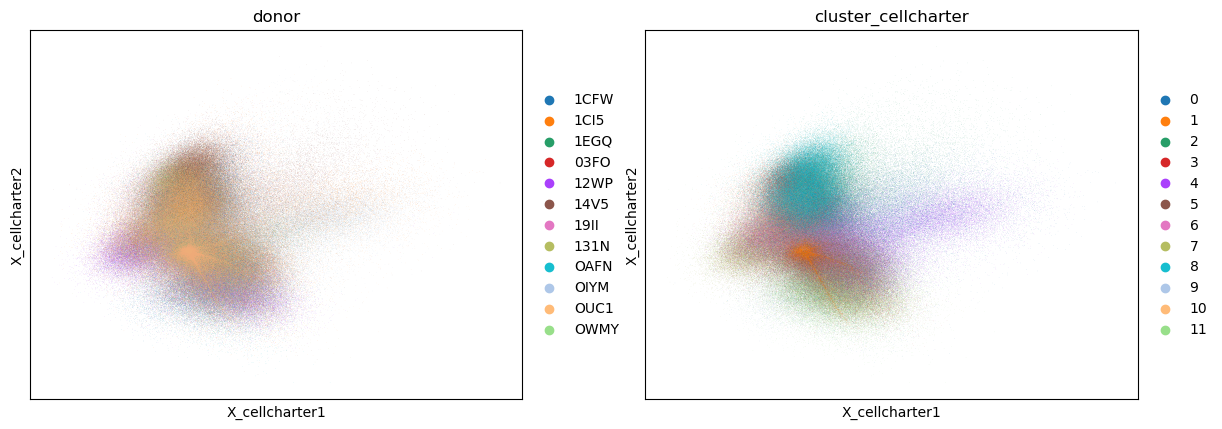

In [ ]:
adata.obs['cluster_cellcharter'] = autok.predict(adata, use_rep='X_cellcharter')
sc.pl.embedding(adata, basis='X_cellcharter',color=['donor','cluster_cellcharter']) 

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


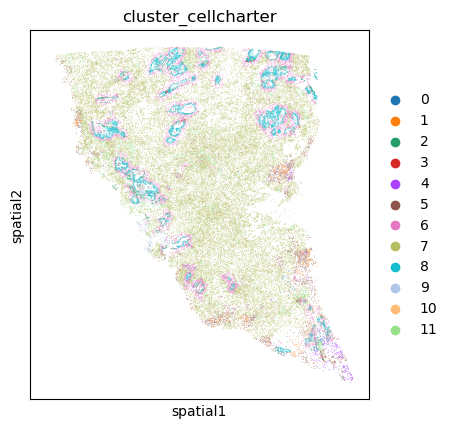

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


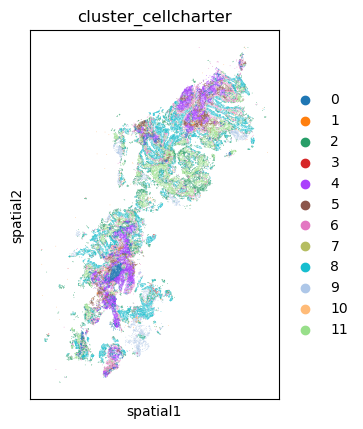

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


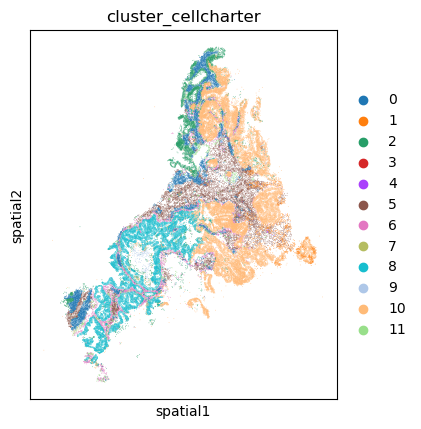

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


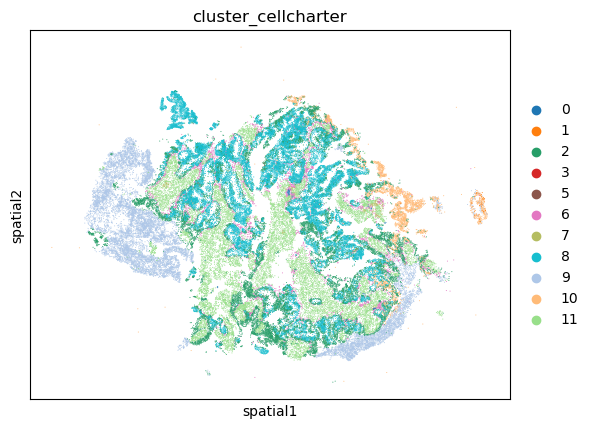

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


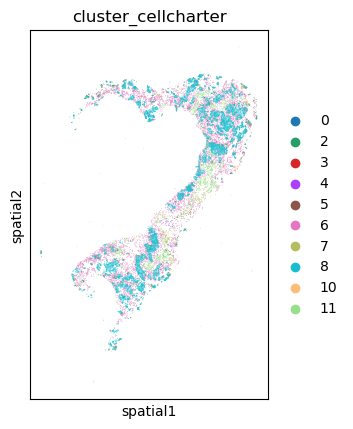

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


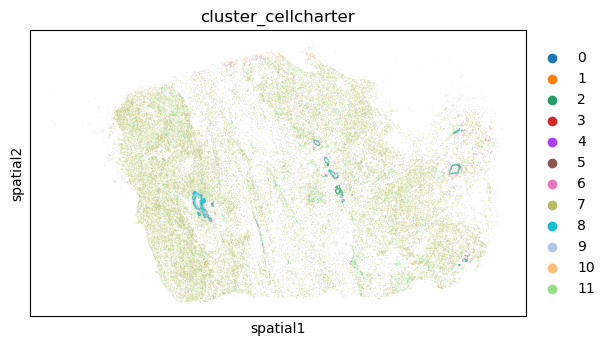

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


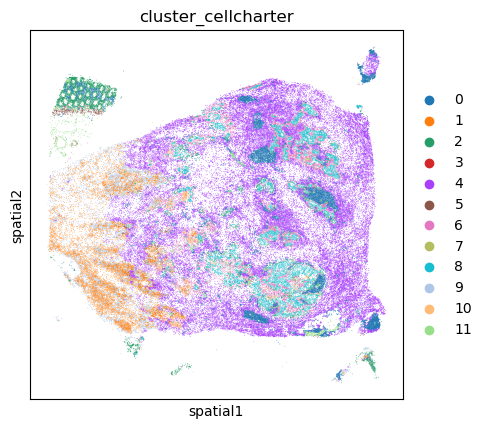

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


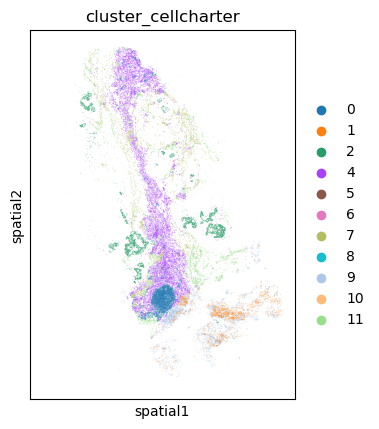

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


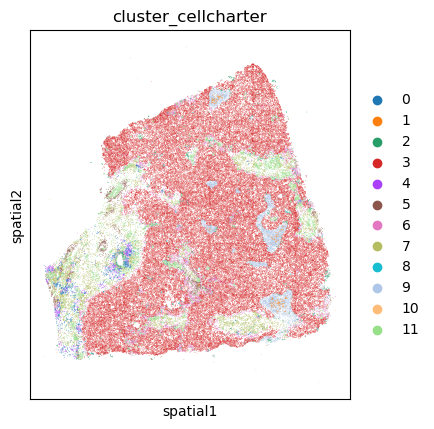

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


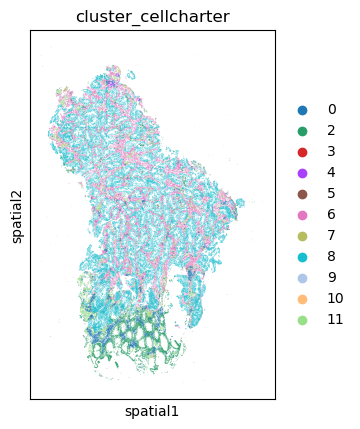

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


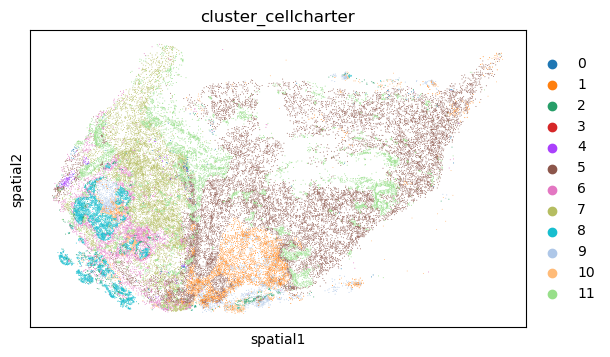

/tmp/ipykernel_1108140/1390377688.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)


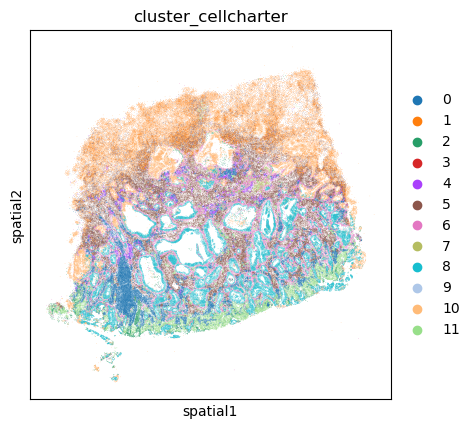

In [118]:
for d in adata.obs['donor'].unique():
    sc.pl.spatial(adata[adata.obs['donor']==d],color=['cluster_cellcharter'],spot_size=10)